# LR3: Transformer EN->RU Pipeline

Ноутбук оформлен как самостоятельная версия лабораторной работы по переводу `en -> ru`.

- Сохранен модульный сценарий: данные, модель, метрики, обучение, артефакты и демонстрация перевода.
- По смыслу используется рабочее решение из экспериментальной тетрадки, но структура, формулировки и названия адаптированы под `LR3.ipynb`.
- Финальный сценарий ориентирован на воспроизводимый запуск и удобную демонстрацию результатов.


## 1. Импорты, сиды, пресеты и общие настройки


In [1]:
from collections import Counter
from pathlib import Path
from typing import Optional
import json
import math
import random
import re

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer

import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm


/Users/daniil.lukin/Git/AdvencedML-ITMO-26/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Настройка окружения


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
device


device(type='mps')

### Конфигурация основного эксперимента


In [3]:
DATASET_NAME = "opus100"
LANG_PAIR = "en-ru"
TOKENIZER_NAME = "Helsinki-NLP/opus-mt-en-ru"

EXPERIMENT_NAME = "final_lr3_run"
EXPERIMENT_COMMENT = "Основной запуск LR3: очистка данных, компактный словарь и стабильное обучение трансформера."

MAX_SAMPLES = 160000
MAX_SRC_WORDS = 40
MAX_TGT_WORDS = 45
MAX_SOURCE_TOKENS = 112
MAX_TARGET_TOKENS = 112

BATCH_SIZE = 96
NUM_EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
CLIP_GRAD_NORM = 1.0
WARMUP_RATIO = 0.10
LABEL_SMOOTHING = 0.05
EARLY_STOPPING_PATIENCE = 3

D_MODEL = 512
NHEAD = 8
NUM_ENCODER_LAYERS = 5
NUM_DECODER_LAYERS = 5
DIM_FEEDFORWARD = 1536
DROPOUT = 0.10

BEAM_SIZE = 4
LENGTH_PENALTY = 0.90
NO_REPEAT_NGRAM_SIZE = 3
REPETITION_PENALTY = 1.10

MIN_LENGTH_RATIO = 0.5
MAX_LENGTH_RATIO = 2.5
REMOVE_DUPLICATES = True
REMOVE_IDENTICAL_PAIRS = True

TRAIN_SIZE = 0.90
VAL_SIZE = 0.05
TEST_SIZE = 0.05

VALIDATION_METRIC_SAMPLES = 120
VALIDATION_TEXT_EVERY = 2
VALIDATION_BEAM_SIZE = 1
RUN_TRAINING = False

ARTIFACTS_ROOT = Path("artifacts/lr3_runs")
EXPERIMENT_DIR = ARTIFACTS_ROOT / EXPERIMENT_NAME
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = EXPERIMENT_DIR / "transformer_en_ru.pt"
HISTORY_PATH = EXPERIMENT_DIR / "history.json"
CONFIG_PATH = EXPERIMENT_DIR / "model_config.json"
SUMMARY_PATH = EXPERIMENT_DIR / "experiment_summary.json"
TOKENIZER_DIR = EXPERIMENT_DIR / "tokenizer"
VOCAB_IDS_PATH = EXPERIMENT_DIR / "compact_vocab_ids.json"

pd.DataFrame(
    [
        {
            "experiment_name": EXPERIMENT_NAME,
            "comment": EXPERIMENT_COMMENT,
            "max_samples": MAX_SAMPLES,
            "batch_size": BATCH_SIZE,
            "num_epochs": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "d_model": D_MODEL,
            "num_encoder_layers": NUM_ENCODER_LAYERS,
            "num_decoder_layers": NUM_DECODER_LAYERS,
            "dim_feedforward": DIM_FEEDFORWARD,
            "dropout": DROPOUT,
            "beam_size": BEAM_SIZE,
        }
    ]
)


,experiment_name,comment,max_samples,batch_size,num_epochs,learning_rate,d_model,num_encoder_layers,num_decoder_layers,dim_feedforward,dropout,beam_size
0,final_lr3_run,"Основной запуск LR3: очистка данных, компактны...",160000,96,10,0.0003,512,5,5,1536,0.1,4


## 2. Подготовка данных и dynamic padding


In [4]:
raw_dataset = load_dataset(DATASET_NAME, LANG_PAIR, split="train")

if MAX_SAMPLES is not None and MAX_SAMPLES < len(raw_dataset):
    raw_dataset = raw_dataset.shuffle(seed=SEED).select(range(MAX_SAMPLES))

len(raw_dataset)


Generating validation split: 100%|██████████| 2000/2000 [00:00<00:00, 837437.16 examples/s]


160000

In [5]:
def normalize_text(text: str) -> str:
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


def prepare_record(record):
    src = normalize_text(record["translation"]["en"])
    tgt = normalize_text(record["translation"]["ru"])
    src_words = len(src.split()) if src else 0
    tgt_words = len(tgt.split()) if tgt else 0
    length_ratio = tgt_words / max(src_words, 1)

    return {
        "src": src,
        "tgt": tgt,
        "src_words": src_words,
        "tgt_words": tgt_words,
        "length_ratio": length_ratio,
    }


prepared_df = pd.DataFrame([prepare_record(record) for record in raw_dataset])
initial_size = len(prepared_df)

blank_mask = (prepared_df["src"] == "") | (prepared_df["tgt"] == "")
blank_removed = int(blank_mask.sum())
prepared_df = prepared_df.loc[~blank_mask].copy()

identical_removed = 0
if REMOVE_IDENTICAL_PAIRS:
    identical_mask = prepared_df["src"] == prepared_df["tgt"]
    identical_removed = int(identical_mask.sum())
    prepared_df = prepared_df.loc[~identical_mask].copy()

duplicates_removed = 0
if REMOVE_DUPLICATES:
    duplicate_mask = prepared_df.duplicated(subset=["src", "tgt"], keep="first")
    duplicates_removed = int(duplicate_mask.sum())
    prepared_df = prepared_df.loc[~duplicate_mask].copy()

length_mask = (
    (prepared_df["src_words"] >= 1)
    & (prepared_df["tgt_words"] >= 1)
    & (prepared_df["src_words"] <= MAX_SRC_WORDS)
    & (prepared_df["tgt_words"] <= MAX_TGT_WORDS)
    & (prepared_df["length_ratio"] >= MIN_LENGTH_RATIO)
    & (prepared_df["length_ratio"] <= MAX_LENGTH_RATIO)
)
length_removed = int((~length_mask).sum())
prepared_df = prepared_df.loc[length_mask].reset_index(drop=True)

clean_dataset = Dataset.from_pandas(prepared_df, preserve_index=False)

filtering_stats_df = pd.DataFrame(
    {
        "metric": [
            "initial_size",
            "blank_removed",
            "identical_removed",
            "duplicates_removed",
            "length_removed",
            "final_size",
        ],
        "value": [
            initial_size,
            blank_removed,
            identical_removed,
            duplicates_removed,
            length_removed,
            len(prepared_df),
        ],
    }
)

filtering_stats_df


,metric,value
0,initial_size,160000
1,blank_removed,0
2,identical_removed,3701
3,duplicates_removed,3866
4,length_removed,14735
5,final_size,137698


In [6]:
train_valid = clean_dataset.train_test_split(test_size=(1.0 - TRAIN_SIZE), seed=SEED)
valid_test = train_valid["test"].train_test_split(test_size=0.5, seed=SEED)

dataset_dict = DatasetDict(
    {
        "train": train_valid["train"],
        "validation": valid_test["train"],
        "test": valid_test["test"],
    }
)

stats_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "size": [len(dataset_dict["train"]), len(dataset_dict["validation"]), len(dataset_dict["test"])],
        "avg_src_words": [
            np.mean(dataset_dict[split]["src_words"]) for split in ["train", "validation", "test"]
        ],
        "avg_tgt_words": [
            np.mean(dataset_dict[split]["tgt_words"]) for split in ["train", "validation", "test"]
        ],
        "avg_length_ratio": [
            np.mean(dataset_dict[split]["length_ratio"]) for split in ["train", "validation", "test"]
        ],
    }
)

stats_df


,split,size,avg_src_words,avg_tgt_words,avg_length_ratio
0,train,123928,9.661570,8.603697,0.928651
1,validation,6885,9.775454,8.682062,0.929570
2,test,6885,9.551634,8.512564,0.927848


In [7]:
pd.DataFrame(dataset_dict["train"][:5])[["src", "tgt", "src_words", "tgt_words", "length_ratio"]]


,src,tgt,src_words,tgt_words,length_ratio
0,The UNRWA accountability system for gender mai...,Действующая в БАПОР система отчетности за учет...,24,27,1.125000
1,Will you do it?,Сделаешь это?,4,2,0.500000
2,"It's called ""Male Flame"".",Называется Мужской Жар.,4,3,0.750000
3,"Furthermore, the use of PSCs in conflict zones...","К тому же использование ЧОК в зонах конфликта,...",30,32,1.066667
4,I don't believe she is my child.,"Я не верю, что это мой ребенок.",7,7,1.000000


### Токенизация и compact vocabulary


In [8]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

special_tokens_to_add = {}
if tokenizer.pad_token is None:
    special_tokens_to_add["pad_token"] = "<pad>"
if tokenizer.bos_token is None:
    special_tokens_to_add["bos_token"] = "<bos>"
if tokenizer.eos_token is None:
    special_tokens_to_add["eos_token"] = "<eos>"

if special_tokens_to_add:
    tokenizer.add_special_tokens(special_tokens_to_add)

BASE_PAD_IDX = tokenizer.pad_token_id
BASE_BOS_IDX = tokenizer.bos_token_id
BASE_EOS_IDX = tokenizer.eos_token_id
BASE_UNK_IDX = tokenizer.unk_token_id


def build_compact_vocabulary(dataset_dict, tokenizer):
    used_token_ids = {BASE_PAD_IDX, BASE_BOS_IDX, BASE_EOS_IDX}
    if BASE_UNK_IDX is not None:
        used_token_ids.add(BASE_UNK_IDX)

    for split in dataset_dict.values():
        for src_text, tgt_text in zip(split["src"], split["tgt"]):
            used_token_ids.update(tokenizer.encode(normalize_text(src_text), add_special_tokens=False))
            used_token_ids.update(tokenizer.encode(normalize_text(tgt_text), add_special_tokens=False))

    special_ids = [BASE_PAD_IDX, BASE_BOS_IDX, BASE_EOS_IDX]
    if BASE_UNK_IDX is not None and BASE_UNK_IDX not in special_ids:
        special_ids.append(BASE_UNK_IDX)

    compact_token_ids = []
    for token_id in special_ids + sorted(used_token_ids):
        if token_id not in compact_token_ids:
            compact_token_ids.append(token_id)

    old_to_new = {old_id: new_id for new_id, old_id in enumerate(compact_token_ids)}
    new_to_old = {new_id: old_id for new_id, old_id in enumerate(compact_token_ids)}
    return compact_token_ids, old_to_new, new_to_old


COMPACT_TOKEN_IDS, BASE_TO_MODEL_ID, MODEL_TO_BASE_ID = build_compact_vocabulary(dataset_dict, tokenizer)

PAD_IDX = BASE_TO_MODEL_ID[BASE_PAD_IDX]
BOS_IDX = BASE_TO_MODEL_ID[BASE_BOS_IDX]
EOS_IDX = BASE_TO_MODEL_ID[BASE_EOS_IDX]
UNK_IDX = BASE_TO_MODEL_ID.get(BASE_UNK_IDX, PAD_IDX)
VOCAB_SIZE = len(COMPACT_TOKEN_IDS)

len(tokenizer), VOCAB_SIZE, PAD_IDX, BOS_IDX, EOS_IDX


(62519, 28082, 0, 1, 2)

In [9]:
class TranslationCollator:
    def __init__(self, tokenizer, token_id_map, max_source_tokens: int, max_target_tokens: int):
        self.tokenizer = tokenizer
        self.token_id_map = token_id_map
        self.max_source_tokens = max_source_tokens
        self.max_target_tokens = max_target_tokens

    def _remap_tokens(self, token_ids):
        return [self.token_id_map.get(token_id, UNK_IDX) for token_id in token_ids]

    def _encode_source(self, text: str) -> torch.Tensor:
        text = normalize_text(text)
        token_ids = self.tokenizer.encode(text, add_special_tokens=False)
        token_ids = self._remap_tokens(token_ids[: self.max_source_tokens - 1]) + [EOS_IDX]
        return torch.tensor(token_ids, dtype=torch.long)

    def _encode_target(self, text: str) -> torch.Tensor:
        text = normalize_text(text)
        token_ids = self.tokenizer.encode(text, add_special_tokens=False)
        token_ids = [BOS_IDX] + self._remap_tokens(token_ids[: self.max_target_tokens - 2]) + [EOS_IDX]
        return torch.tensor(token_ids, dtype=torch.long)

    def __call__(self, batch):
        src_sequences = [self._encode_source(item["src"]) for item in batch]
        tgt_sequences = [self._encode_target(item["tgt"]) for item in batch]

        src_batch = pad_sequence(src_sequences, batch_first=True, padding_value=PAD_IDX)
        tgt_batch = pad_sequence(tgt_sequences, batch_first=True, padding_value=PAD_IDX)

        return {
            "src_input_ids": src_batch,
            "tgt_input_ids": tgt_batch,
            "src_text": [item["src"] for item in batch],
            "tgt_text": [item["tgt"] for item in batch],
        }


def make_dataloader(dataset, shuffle: bool) -> DataLoader:
    num_workers = 2 if device.type == "cuda" else 0
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=TranslationCollator(
            tokenizer=tokenizer,
            token_id_map=BASE_TO_MODEL_ID,
            max_source_tokens=MAX_SOURCE_TOKENS,
            max_target_tokens=MAX_TARGET_TOKENS,
        ),
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
    )


train_loader = make_dataloader(dataset_dict["train"], shuffle=True)
valid_loader = make_dataloader(dataset_dict["validation"], shuffle=False)
test_loader = make_dataloader(dataset_dict["test"], shuffle=False)


In [10]:
sample_batch = next(iter(train_loader))
sample_batch["src_input_ids"].shape, sample_batch["tgt_input_ids"].shape


(torch.Size([96, 101]), torch.Size([96, 112]))

## 3. Модель и декодирование


In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerTranslationModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        nhead: int,
        num_encoder_layers: int,
        num_decoder_layers: int,
        dim_feedforward: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()

        self.pad_idx = pad_idx
        self.d_model = d_model

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.output_layer = nn.Linear(d_model, vocab_size, bias=False)
        self.output_layer.weight = self.token_embedding.weight

    def encode(
        self,
        src: torch.Tensor,
        src_mask: Optional[torch.Tensor] = None,
        src_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        src_emb = self.positional_encoding(self.token_embedding(src) * math.sqrt(self.d_model))
        return self.transformer.encoder(
            src_emb,
            mask=src_mask,
            src_key_padding_mask=src_padding_mask,
        )

    def decode(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: Optional[torch.Tensor] = None,
        tgt_padding_mask: Optional[torch.Tensor] = None,
        memory_key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        tgt_emb = self.positional_encoding(self.token_embedding(tgt) * math.sqrt(self.d_model))
        hidden = self.transformer.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.output_layer(hidden)

    def forward(
        self,
        src: torch.Tensor,
        tgt: torch.Tensor,
        src_mask: Optional[torch.Tensor] = None,
        tgt_mask: Optional[torch.Tensor] = None,
        src_padding_mask: Optional[torch.Tensor] = None,
        tgt_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        memory = self.encode(src, src_mask=src_mask, src_padding_mask=src_padding_mask)
        return self.decode(
            tgt,
            memory,
            tgt_mask=tgt_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )


In [12]:
def generate_square_subsequent_mask(size: int, device: torch.device) -> torch.Tensor:
    return torch.triu(torch.ones(size, size, device=device, dtype=torch.bool), diagonal=1)


def create_padding_mask(tokens: torch.Tensor, pad_idx: int) -> torch.Tensor:
    return tokens.eq(pad_idx)


def build_model() -> TransformerTranslationModel:
    model = TransformerTranslationModel(
        vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_encoder_layers=NUM_ENCODER_LAYERS,
        num_decoder_layers=NUM_DECODER_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        pad_idx=PAD_IDX,
    )

    for param in model.parameters():
        if param.dim() > 1:
            nn.init.xavier_uniform_(param)

    return model.to(device)


model = build_model()
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.98))

total_training_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = max(1, int(total_training_steps * WARMUP_RATIO))


def lr_lambda(current_step: int) -> float:
    if current_step < warmup_steps:
        return float(current_step + 1) / float(warmup_steps)

    progress = (current_step - warmup_steps) / max(1, total_training_steps - warmup_steps)
    cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
    return max(0.1, cosine_decay)


scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

sum(p.numel() for p in model.parameters())


/Users/daniil.lukin/Git/AdvencedML-ITMO-26/.venv/lib/python3.14/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


45914112

## 4. Scheduler и переводческие метрики


In [13]:
def _count_metrics(logits: torch.Tensor, target: torch.Tensor):
    non_pad_mask = target.ne(PAD_IDX)
    token_count = non_pad_mask.sum().item()
    predictions = logits.argmax(dim=-1)
    correct_count = ((predictions == target) & non_pad_mask).sum().item()
    return token_count, correct_count


def _extract_word_ngrams(tokens, n: int) -> Counter:
    if len(tokens) < n:
        return Counter()
    return Counter(tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1))


def compute_corpus_bleu(references, predictions, max_n: int = 4) -> float:
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_length = 0
    pred_length = 0

    for ref_text, pred_text in zip(references, predictions):
        ref_tokens = normalize_text(ref_text).split()
        pred_tokens = normalize_text(pred_text).split()

        ref_length += len(ref_tokens)
        pred_length += len(pred_tokens)

        for n in range(1, max_n + 1):
            ref_ngrams = _extract_word_ngrams(ref_tokens, n)
            pred_ngrams = _extract_word_ngrams(pred_tokens, n)
            clipped_counts[n - 1] += sum(min(count, ref_ngrams[ngram]) for ngram, count in pred_ngrams.items())
            total_counts[n - 1] += sum(pred_ngrams.values())

    precisions = []
    for clipped_count, total_count in zip(clipped_counts, total_counts):
        precisions.append(clipped_count / total_count if total_count > 0 else 0.0)

    if min(precisions, default=0.0) == 0.0:
        geo_mean = 0.0
    else:
        geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)

    if pred_length == 0:
        brevity_penalty = 0.0
    elif pred_length > ref_length:
        brevity_penalty = 1.0
    else:
        brevity_penalty = math.exp(1.0 - ref_length / pred_length)

    return 100.0 * brevity_penalty * geo_mean


def _extract_char_ngrams(text: str, n: int) -> Counter:
    normalized = normalize_text(text).replace(" ", "")
    if len(normalized) < n:
        return Counter()
    return Counter(normalized[i : i + n] for i in range(len(normalized) - n + 1))


def compute_corpus_chrf(references, predictions, max_n: int = 6, beta: float = 2.0) -> float:
    beta_sq = beta ** 2
    f_scores = []

    for n in range(1, max_n + 1):
        overlap = 0
        pred_total = 0
        ref_total = 0

        for ref_text, pred_text in zip(references, predictions):
            ref_ngrams = _extract_char_ngrams(ref_text, n)
            pred_ngrams = _extract_char_ngrams(pred_text, n)

            overlap += sum(min(count, ref_ngrams[ngram]) for ngram, count in pred_ngrams.items())
            pred_total += sum(pred_ngrams.values())
            ref_total += sum(ref_ngrams.values())

        precision = overlap / pred_total if pred_total > 0 else 0.0
        recall = overlap / ref_total if ref_total > 0 else 0.0

        if precision == 0.0 and recall == 0.0:
            f_score = 0.0
        else:
            f_score = (1 + beta_sq) * precision * recall / (beta_sq * precision + recall)

        f_scores.append(f_score)

    return 100.0 * float(np.mean(f_scores))


def decode_token_ids(token_ids, tokenizer, id_to_token_map) -> str:
    base_token_ids = [id_to_token_map[token_id] for token_id in token_ids if token_id in id_to_token_map]
    return tokenizer.decode(base_token_ids, skip_special_tokens=True).strip()


def greedy_decode_batch(model, src, src_padding_mask, max_target_tokens: int, bos_idx: int, eos_idx: int, pad_idx: int):
    batch_size = src.size(0)
    generated = torch.full((batch_size, 1), bos_idx, dtype=torch.long, device=src.device)
    memory = model.encode(src, src_padding_mask=src_padding_mask)
    finished = torch.zeros(batch_size, dtype=torch.bool, device=src.device)

    for _ in range(max_target_tokens - 1):
        tgt_mask = generate_square_subsequent_mask(generated.size(1), src.device)
        tgt_padding_mask = create_padding_mask(generated, pad_idx)

        logits = model.decode(
            tgt=generated,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        next_token = logits[:, -1, :].argmax(dim=-1)
        next_token = next_token.masked_fill(finished, pad_idx)
        generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
        finished = finished | next_token.eq(eos_idx)

        if bool(finished.all()):
            break

    return generated


def train_epoch(model, dataloader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    total_correct = 0

    progress = tqdm(dataloader, desc="train", leave=False)
    for batch in progress:
        src = batch["src_input_ids"].to(device, non_blocking=True)
        tgt = batch["tgt_input_ids"].to(device, non_blocking=True)

        tgt_input = tgt[:, :-1]
        tgt_expected = tgt[:, 1:]

        tgt_mask = generate_square_subsequent_mask(tgt_input.size(1), device)
        src_padding_mask = create_padding_mask(src, PAD_IDX)
        tgt_padding_mask = create_padding_mask(tgt_input, PAD_IDX)

        optimizer.zero_grad(set_to_none=True)

        logits = model(
            src=src,
            tgt=tgt_input,
            src_mask=None,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
        )

        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_expected.reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        token_count, correct_count = _count_metrics(logits, tgt_expected)
        total_loss += loss.item() * token_count
        total_tokens += token_count
        total_correct += correct_count

        progress.set_postfix(
            loss=f"{total_loss / max(1, total_tokens):.4f}",
            acc=f"{total_correct / max(1, total_tokens):.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

    return total_loss / max(1, total_tokens), total_correct / max(1, total_tokens)


def evaluate_epoch(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    total_correct = 0

    with torch.no_grad():
        progress = tqdm(dataloader, desc="valid", leave=False)
        for batch in progress:
            src = batch["src_input_ids"].to(device, non_blocking=True)
            tgt = batch["tgt_input_ids"].to(device, non_blocking=True)

            tgt_input = tgt[:, :-1]
            tgt_expected = tgt[:, 1:]

            tgt_mask = generate_square_subsequent_mask(tgt_input.size(1), device)
            src_padding_mask = create_padding_mask(src, PAD_IDX)
            tgt_padding_mask = create_padding_mask(tgt_input, PAD_IDX)

            logits = model(
                src=src,
                tgt=tgt_input,
                src_mask=None,
                tgt_mask=tgt_mask,
                src_padding_mask=src_padding_mask,
                tgt_padding_mask=tgt_padding_mask,
            )

            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_expected.reshape(-1))
            token_count, correct_count = _count_metrics(logits, tgt_expected)
            total_loss += loss.item() * token_count
            total_tokens += token_count
            total_correct += correct_count
            progress.set_postfix(
                loss=f"{total_loss / max(1, total_tokens):.4f}",
                acc=f"{total_correct / max(1, total_tokens):.4f}",
            )

    return total_loss / max(1, total_tokens), total_correct / max(1, total_tokens)


valid_metric_dataset = dataset_dict["validation"].select(
    range(min(VALIDATION_METRIC_SAMPLES, len(dataset_dict["validation"])))
)
valid_metric_loader = make_dataloader(valid_metric_dataset, shuffle=False)


def evaluate_translation_metrics(model, dataloader, tokenizer, id_to_token_map):
    model.eval()
    predictions = []
    references = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="validation text", leave=False):
            src = batch["src_input_ids"].to(device, non_blocking=True)
            src_padding_mask = create_padding_mask(src, PAD_IDX)
            generated = greedy_decode_batch(
                model,
                src,
                src_padding_mask,
                max_target_tokens=MAX_TARGET_TOKENS,
                bos_idx=BOS_IDX,
                eos_idx=EOS_IDX,
                pad_idx=PAD_IDX,
            )

            for token_ids in generated.detach().cpu().tolist():
                predictions.append(decode_token_ids(token_ids, tokenizer, id_to_token_map))

            references.extend(batch["tgt_text"])

    bleu = compute_corpus_bleu(references, predictions)
    chrf = compute_corpus_chrf(references, predictions)
    return bleu, chrf


In [14]:
history = {
    "train_loss": [],
    "valid_loss": [],
    "train_acc": [],
    "valid_acc": [],
    "valid_bleu": [],
    "valid_chrf": [],
    "learning_rate": [],
}
best_valid_loss = float("inf")
best_valid_chrf = float("-inf")
best_valid_bleu = float("-inf")
last_valid_chrf = float("-inf")
last_valid_bleu = 0.0
best_epoch = 0
epochs_without_improvement = 0

if RUN_TRAINING:
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        valid_loss, valid_acc = evaluate_epoch(model, valid_loader, criterion)

        should_eval_text = (epoch == 1) or (epoch % VALIDATION_TEXT_EVERY == 0) or (epoch == NUM_EPOCHS)
        if should_eval_text:
            valid_bleu, valid_chrf = evaluate_translation_metrics(
                model,
                valid_metric_loader,
                tokenizer,
                MODEL_TO_BASE_ID,
            )
            last_valid_bleu = valid_bleu
            last_valid_chrf = valid_chrf
        else:
            valid_bleu = last_valid_bleu
            valid_chrf = last_valid_chrf
        current_lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)
        history["valid_bleu"].append(valid_bleu)
        history["valid_chrf"].append(valid_chrf)
        history["learning_rate"].append(current_lr)

        metric_tag = "fresh" if should_eval_text else "cached"
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss = {train_loss:.4f} | train_acc = {train_acc:.4f} | "
            f"valid_loss = {valid_loss:.4f} | valid_acc = {valid_acc:.4f} | "
            f"valid_bleu = {valid_bleu:.2f} | valid_chrf = {valid_chrf:.2f} | "
            f"text_metrics = {metric_tag} | lr = {current_lr:.2e}"
        )

        is_better = (valid_chrf > best_valid_chrf) or (
            math.isclose(valid_chrf, best_valid_chrf) and valid_loss < best_valid_loss
        )

        if is_better:
            best_valid_loss = valid_loss
            best_valid_chrf = valid_chrf
            best_valid_bleu = valid_bleu
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(model.state_dict(), MODEL_PATH)
            tokenizer.save_pretrained(TOKENIZER_DIR)

            model_config = {
                "experiment_name": EXPERIMENT_NAME,
                "experiment_comment": EXPERIMENT_COMMENT,
                "d_model": D_MODEL,
                "nhead": NHEAD,
                "num_encoder_layers": NUM_ENCODER_LAYERS,
                "num_decoder_layers": NUM_DECODER_LAYERS,
                "dim_feedforward": DIM_FEEDFORWARD,
                "dropout": DROPOUT,
                "pad_idx": PAD_IDX,
                "max_source_tokens": MAX_SOURCE_TOKENS,
                "max_target_tokens": MAX_TARGET_TOKENS,
                "beam_size": BEAM_SIZE,
                "length_penalty": LENGTH_PENALTY,
                "no_repeat_ngram_size": NO_REPEAT_NGRAM_SIZE,
                "repetition_penalty": REPETITION_PENALTY,
                "base_pad_idx": BASE_PAD_IDX,
                "base_bos_idx": BASE_BOS_IDX,
                "base_eos_idx": BASE_EOS_IDX,
                "base_unk_idx": BASE_UNK_IDX,
                "tokenizer_dir": str(TOKENIZER_DIR),
                "vocab_ids_path": str(VOCAB_IDS_PATH),
                "selection_beam_size": VALIDATION_BEAM_SIZE,
            }

            with open(CONFIG_PATH, "w", encoding="utf-8") as f:
                json.dump(model_config, f, ensure_ascii=False, indent=2)

            with open(VOCAB_IDS_PATH, "w", encoding="utf-8") as f:
                json.dump(COMPACT_TOKEN_IDS, f)

            with open(HISTORY_PATH, "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)

            summary = {
                "experiment_name": EXPERIMENT_NAME,
                "comment": EXPERIMENT_COMMENT,
                "train_size": len(dataset_dict["train"]),
                "validation_size": len(dataset_dict["validation"]),
                "test_size": len(dataset_dict["test"]),
                "best_epoch": best_epoch,
                "best_valid_loss": best_valid_loss,
                "best_valid_bleu": best_valid_bleu,
                "best_valid_chrf": best_valid_chrf,
                "d_model": D_MODEL,
                "num_encoder_layers": NUM_ENCODER_LAYERS,
                "num_decoder_layers": NUM_DECODER_LAYERS,
                "dim_feedforward": DIM_FEEDFORWARD,
                "dropout": DROPOUT,
                "learning_rate": LEARNING_RATE,
                "label_smoothing": LABEL_SMOOTHING,
                "beam_size": BEAM_SIZE,
            }

            with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
                json.dump(summary, f, ensure_ascii=False, indent=2)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping: valid_chrf не улучшается уже {EARLY_STOPPING_PATIENCE} эпох(и).")
                break
else:
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH, "r", encoding="utf-8") as f:
            history = json.load(f)
    if SUMMARY_PATH.exists():
        with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
            summary = json.load(f)
        best_valid_loss = summary["best_valid_loss"]
        best_valid_bleu = summary["best_valid_bleu"]
        best_valid_chrf = summary["best_valid_chrf"]
        best_epoch = summary["best_epoch"]

history


{'train_loss': [3.955395841324957,
  2.352297595075258,
  2.0212216809596795,
  1.861854668621121,
  1.7609148847940528,
  1.6863608668412704,
  1.6289882355756908,
  1.5870641447565197,
  1.5614953713747035,
  1.5516932180317096],
 'valid_loss': [2.551607522109404,
  2.063969261943021,
  1.8672036210924305,
  1.7719110889036025,
  1.7057225533315847,
  1.661193824452904,
  1.635188560103911,
  1.616786582902569,
  1.610227745049536,
  1.6073719195373988],
 'train_acc': [0.27997686061166643,
  0.5129384272562313,
  0.6132906605471892,
  0.6601621021444083,
  0.6892797352843041,
  0.7109384009459404,
  0.7274207731364413,
  0.7394625149255376,
  0.7469829869799938,
  0.7499247850286928],
 'valid_acc': [0.4538087915842913,
  0.6029630714407752,
  0.6626394278880183,
  0.6912511288472334,
  0.7113720680481316,
  0.7242927924629616,
  0.734055795562715,
  0.739663420468136,
  0.7423146859974128,
  0.7440598228014937],
 'valid_bleu': [0.7166841017688194,
  1.408318723205229,
  1.40831872320

## 5. Обучение, валидация, графики и выбор лучшей модели


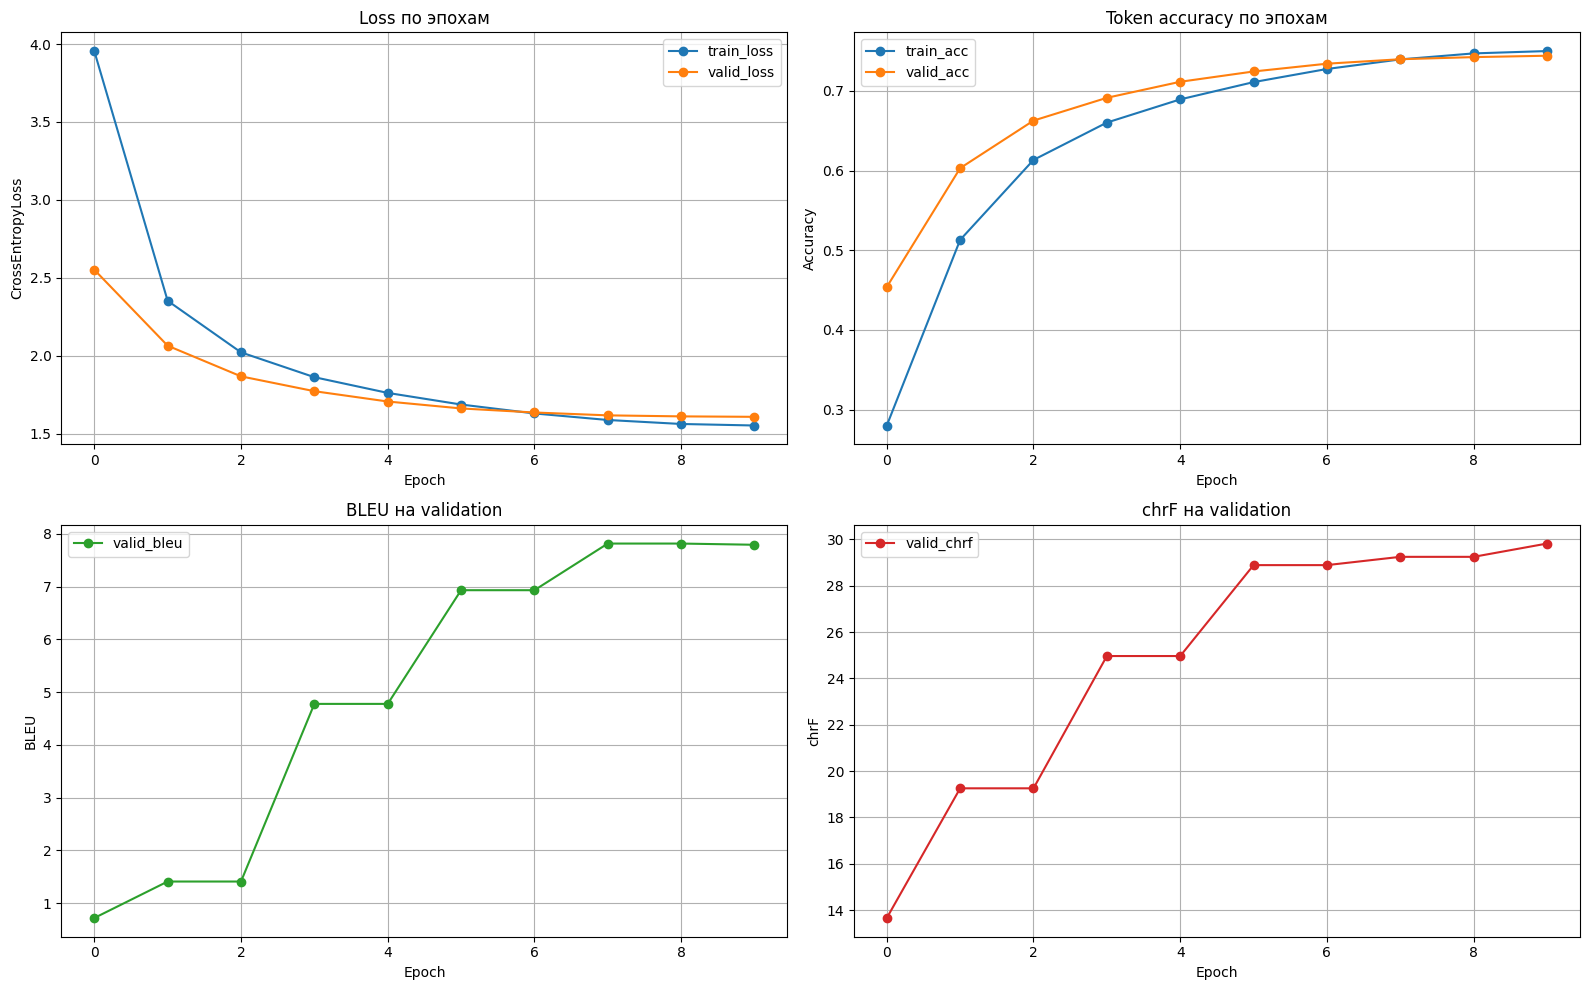

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

axes[0].plot(history.get("train_loss", []), label="train_loss", marker="o")
axes[0].plot(history.get("valid_loss", []), label="valid_loss", marker="o")
axes[0].set_title("Loss по эпохам")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history.get("train_acc", []), label="train_acc", marker="o")
axes[1].plot(history.get("valid_acc", []), label="valid_acc", marker="o")
axes[1].set_title("Token accuracy по эпохам")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(history.get("valid_bleu", []), label="valid_bleu", marker="o", color="tab:green")
axes[2].set_title("BLEU на validation")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("BLEU")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(history.get("valid_chrf", []), label="valid_chrf", marker="o", color="tab:red")
axes[3].set_title("chrF на validation")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("chrF")
axes[3].grid(True)
axes[3].legend()

plt.tight_layout()
plt.show()


## 6. Сохранение артефактов и запуск эксперимента


In [16]:
def load_trained_artifacts(model_path: Path, config_path: Path):
    if not model_path.exists() or not config_path.exists():
        raise FileNotFoundError("Сначала обучите модель, чтобы появились checkpoint и config.")

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    with open(config["vocab_ids_path"], "r", encoding="utf-8") as f:
        compact_token_ids = json.load(f)

    inference_tokenizer = AutoTokenizer.from_pretrained(config["tokenizer_dir"])
    base_to_model = {base_id: model_id for model_id, base_id in enumerate(compact_token_ids)}
    model_to_base = {model_id: base_id for model_id, base_id in enumerate(compact_token_ids)}

    inference_model = TransformerTranslationModel(
        vocab_size=len(compact_token_ids),
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_encoder_layers=config["num_encoder_layers"],
        num_decoder_layers=config["num_decoder_layers"],
        dim_feedforward=config["dim_feedforward"],
        dropout=config["dropout"],
        pad_idx=base_to_model[config["base_pad_idx"]],
    ).to(device)

    state_dict = torch.load(model_path, map_location=device)
    inference_model.load_state_dict(state_dict)
    inference_model.eval()

    return inference_model, inference_tokenizer, config, base_to_model, model_to_base


def encode_source_text(text: str, tokenizer, token_id_map, eos_idx: int, unk_idx: int, max_source_tokens: int) -> torch.Tensor:
    text = normalize_text(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    token_ids = [token_id_map.get(token_id, unk_idx) for token_id in token_ids[: max_source_tokens - 1]] + [eos_idx]
    return torch.tensor(token_ids, dtype=torch.long).unsqueeze(0)


def prepare_inference_source(model, tokenizer, text, token_id_map, eos_idx: int, unk_idx: int, pad_idx: int, max_source_tokens: int):
    src = encode_source_text(text, tokenizer, token_id_map, eos_idx, unk_idx, max_source_tokens).to(device)
    src_padding_mask = create_padding_mask(src, pad_idx)
    memory = model.encode(src, src_padding_mask=src_padding_mask)
    return src_padding_mask, memory


def _has_repeat_ngram(token_ids, next_token, ngram_size: int) -> bool:
    if ngram_size <= 1 or len(token_ids) < ngram_size - 1:
        return False
    candidate = tuple(token_ids[-(ngram_size - 1):] + [next_token])
    existing = {tuple(token_ids[i : i + ngram_size]) for i in range(len(token_ids) - ngram_size + 1)}
    return candidate in existing


def _apply_repetition_controls(logits, token_ids, repetition_penalty: float, no_repeat_ngram_size: int):
    adjusted_logits = logits.clone()
    for token_id in set(token_ids):
        adjusted_logits[..., token_id] /= repetition_penalty

    if no_repeat_ngram_size > 1:
        for token_id in range(adjusted_logits.size(-1)):
            if _has_repeat_ngram(token_ids, token_id, no_repeat_ngram_size):
                adjusted_logits[..., token_id] = float("-inf")

    return adjusted_logits


def greedy_translate(
    model,
    tokenizer,
    text: str,
    token_id_map,
    id_to_token_map,
    max_source_tokens: int,
    max_target_tokens: int,
    bos_idx: int,
    eos_idx: int,
    pad_idx: int,
    unk_idx: int,
    repetition_penalty: float = 1.0,
    no_repeat_ngram_size: int = 0,
):
    src_padding_mask, memory = prepare_inference_source(
        model,
        tokenizer,
        text,
        token_id_map,
        eos_idx,
        unk_idx,
        pad_idx,
        max_source_tokens,
    )
    generated = torch.tensor([[bos_idx]], dtype=torch.long, device=device)

    with torch.inference_mode():
        for _ in range(max_target_tokens - 1):
            tgt_mask = generate_square_subsequent_mask(generated.size(1), device)
            tgt_padding_mask = create_padding_mask(generated, pad_idx)

            logits = model.decode(
                tgt=generated,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask,
            )

            step_logits = _apply_repetition_controls(
                logits[:, -1, :],
                generated[0].tolist(),
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
            )
            next_token_id = step_logits.argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token_id], dim=1)
            if next_token_id.item() == eos_idx:
                break

    return decode_token_ids(generated[0].tolist(), tokenizer, id_to_token_map)


def _normalized_score(score: float, length: int, length_penalty: float) -> float:
    return score / (max(length, 1) ** length_penalty)


def beam_translate(
    model,
    tokenizer,
    text: str,
    max_source_tokens: int,
    max_target_tokens: int,
    token_id_map,
    id_to_token_map,
    bos_idx: int,
    eos_idx: int,
    pad_idx: int,
    unk_idx: int,
    beam_size: int = 4,
    length_penalty: float = 0.7,
    repetition_penalty: float = 1.0,
    no_repeat_ngram_size: int = 0,
):
    src_padding_mask, memory = prepare_inference_source(
        model,
        tokenizer,
        text,
        token_id_map,
        eos_idx,
        unk_idx,
        pad_idx,
        max_source_tokens,
    )
    beams = [([bos_idx], 0.0, False)]

    with torch.inference_mode():
        for _ in range(max_target_tokens - 1):
            candidates = []
            for token_ids, score, finished in beams:
                if finished:
                    candidates.append((token_ids, score, finished))
                    continue

                generated = torch.tensor([token_ids], dtype=torch.long, device=device)
                tgt_mask = generate_square_subsequent_mask(generated.size(1), device)
                tgt_padding_mask = create_padding_mask(generated, pad_idx)

                logits = model.decode(
                    tgt=generated,
                    memory=memory,
                    tgt_mask=tgt_mask,
                    tgt_padding_mask=tgt_padding_mask,
                    memory_key_padding_mask=src_padding_mask,
                )

                step_logits = _apply_repetition_controls(
                    logits[:, -1, :],
                    token_ids,
                    repetition_penalty=repetition_penalty,
                    no_repeat_ngram_size=no_repeat_ngram_size,
                )
                log_probs = torch.log_softmax(step_logits, dim=-1)
                top_log_probs, top_indices = torch.topk(log_probs, k=beam_size, dim=-1)

                for log_prob, token_idx in zip(top_log_probs[0], top_indices[0]):
                    next_token = token_idx.item()
                    next_score = score + log_prob.item()
                    next_finished = next_token == eos_idx
                    candidates.append((token_ids + [next_token], next_score, next_finished))

            beams = sorted(
                candidates,
                key=lambda item: _normalized_score(item[1], len(item[0]), length_penalty),
                reverse=True,
            )[:beam_size]

            if all(finished for _, _, finished in beams):
                break

    best_tokens, _, _ = max(
        beams,
        key=lambda item: _normalized_score(item[1], len(item[0]), length_penalty),
    )
    return decode_token_ids(best_tokens, tokenizer, id_to_token_map)


def translate(
    model,
    tokenizer,
    text: str,
    token_id_map,
    id_to_token_map,
    max_source_tokens: int,
    max_target_tokens: int,
    bos_idx: int,
    eos_idx: int,
    pad_idx: int,
    unk_idx: int,
    beam_size: int = 4,
    length_penalty: float = 0.7,
    repetition_penalty: float = 1.0,
    no_repeat_ngram_size: int = 0,
):
    if beam_size <= 1:
        return greedy_translate(
            model,
            tokenizer,
            text,
            token_id_map,
            id_to_token_map,
            max_source_tokens,
            max_target_tokens,
            bos_idx,
            eos_idx,
            pad_idx,
            unk_idx,
            repetition_penalty,
            no_repeat_ngram_size,
        )
    return beam_translate(
        model,
        tokenizer,
        text,
        token_id_map=token_id_map,
        id_to_token_map=id_to_token_map,
        max_source_tokens=max_source_tokens,
        max_target_tokens=max_target_tokens,
        bos_idx=bos_idx,
        eos_idx=eos_idx,
        pad_idx=pad_idx,
        unk_idx=unk_idx,
        beam_size=beam_size,
        length_penalty=length_penalty,
        repetition_penalty=repetition_penalty,
        no_repeat_ngram_size=no_repeat_ngram_size,
    )


inference_model, inference_tokenizer, inference_config, inference_base_to_model, inference_model_to_base = load_trained_artifacts(MODEL_PATH, CONFIG_PATH)


In [17]:
demo_text = "Hello my dear friend. I hope your machine translation model works better today."
translate(
    inference_model,
    inference_tokenizer,
    demo_text,
    token_id_map=inference_base_to_model,
    id_to_token_map=inference_model_to_base,
    max_source_tokens=inference_config["max_source_tokens"],
    max_target_tokens=inference_config["max_target_tokens"],
    bos_idx=inference_base_to_model[inference_config["base_bos_idx"]],
    eos_idx=inference_base_to_model[inference_config["base_eos_idx"]],
    pad_idx=inference_base_to_model[inference_config["base_pad_idx"]],
    unk_idx=inference_base_to_model.get(
        inference_config.get("base_unk_idx"),
        inference_base_to_model[inference_config["base_pad_idx"]],
    ),
    beam_size=inference_config.get("beam_size", BEAM_SIZE),
    length_penalty=inference_config.get("length_penalty", LENGTH_PENALTY),
    repetition_penalty=inference_config.get("repetition_penalty", REPETITION_PENALTY),
    no_repeat_ngram_size=inference_config.get("no_repeat_ngram_size", NO_REPEAT_NGRAM_SIZE),
)


'Здравствуйте мой друг, я надеюсь, что твои машины переводы лучше сегодня.'

## 7. Сводка основного эксперимента и notebook helper


In [18]:
if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
        experiment_summary_df = pd.DataFrame([json.load(f)])
else:
    experiment_summary_df = pd.DataFrame(
        [
            {
                "experiment_name": EXPERIMENT_NAME,
                "comment": EXPERIMENT_COMMENT,
                "status": "Сначала запустите обучение, чтобы получить итоговую сводку.",
            }
        ]
    )

experiment_summary_df


,experiment_name,comment,train_size,validation_size,test_size,best_epoch,best_valid_loss,best_valid_bleu,best_valid_chrf,d_model,num_encoder_layers,num_decoder_layers,dim_feedforward,dropout,learning_rate,label_smoothing,beam_size
0,final_lr3_run,"Основной запуск LR3: очистка данных, компактны...",123928,6885,6885,10,1.607372,7.794375,29.821888,512,5,5,1536,0.1,0.0003,0.05,4


## 8. Примеры перевода и сравнение decoding-режимов


In [19]:
test_df = pd.DataFrame(dataset_dict["test"])
test_df["difficulty"] = pd.cut(
    test_df["src_words"],
    bins=[0, 6, 14, 1000],
    labels=["short", "medium", "long"],
)

short_examples = test_df[test_df["difficulty"] == "short"].head(3).copy()
medium_examples = test_df[test_df["difficulty"] == "medium"].head(3).copy()
long_examples = test_df[test_df["difficulty"] == "long"].head(2).copy()

test_examples = pd.concat([short_examples, medium_examples, long_examples], ignore_index=True)
test_examples["source_type"] = "test"

custom_examples = pd.DataFrame(
    [
        {
            "src": "Hello, how are you?",
            "tgt": "Привет, как дела?",
            "src_words": 4,
            "difficulty": "short",
            "source_type": "custom",
        },
        {
            "src": "The library closes at eight in the evening.",
            "tgt": "Библиотека закрывается в восемь часов вечера.",
            "src_words": 8,
            "difficulty": "short",
            "source_type": "custom",
        },
        {
            "src": "We need to finish the report before Friday.",
            "tgt": "Нам нужно закончить отчет до пятницы.",
            "src_words": 8,
            "difficulty": "short",
            "source_type": "custom",
        },
        {
            "src": "The weather is better today than yesterday.",
            "tgt": "Сегодня погода лучше, чем вчера.",
            "src_words": 7,
            "difficulty": "medium",
            "source_type": "custom",
        },
        {
            "src": "PyTorch makes it convenient to build neural networks from scratch.",
            "tgt": "PyTorch позволяет удобно строить нейронные сети с нуля.",
            "src_words": 10,
            "difficulty": "medium",
            "source_type": "custom",
        },
        {
            "src": "My university project is devoted to machine translation between English and Russian.",
            "tgt": "Мой университетский проект посвящен машинному переводу между английским и русским языками.",
            "src_words": 12,
            "difficulty": "medium",
            "source_type": "custom",
        },
        {
            "src": "If the model sees enough examples, it usually starts to produce more fluent translations.",
            "tgt": "Если модель видит достаточно примеров, она обычно начинает выдавать более плавные переводы.",
            "src_words": 15,
            "difficulty": "medium",
            "source_type": "custom",
        },
        {
            "src": "During the presentation, the reviewer may ask us to translate both a short sentence and a longer paragraph.",
            "tgt": "Во время защиты проверяющий может попросить нас перевести как короткое предложение, так и более длинный абзац.",
            "src_words": 17,
            "difficulty": "medium",
            "source_type": "custom",
        },
        {
            "src": "Although this transformer is much smaller than industrial systems, it still demonstrates how encoder-decoder translation works in practice.",
            "tgt": "Хотя этот трансформер намного меньше промышленных систем, он все равно демонстрирует, как на практике работает encoder-decoder перевод.",
            "src_words": 18,
            "difficulty": "long",
            "source_type": "custom",
        },
        {
            "src": "When I save the checkpoint after each improvement on the validation set, I can later reload the best version and use it for inference without repeating the training stage.",
            "tgt": "Когда я сохраняю чекпоинт после каждого улучшения на валидации, я затем могу загрузить лучшую версию и использовать ее для инференса без повторного этапа обучения.",
            "src_words": 28,
            "difficulty": "long",
            "source_type": "custom",
        },
        {
            "src": "Machine translation becomes more convincing when the model can handle not only short phrases, but also longer sentences with subordinate clauses and technical terms.",
            "tgt": "Машинный перевод выглядит убедительнее, когда модель умеет обрабатывать не только короткие фразы, но и более длинные предложения с придаточными частями и техническими терминами.",
            "src_words": 24,
            "difficulty": "long",
            "source_type": "custom",
        },
        {
            "src": "Our final demonstration should show that the model can translate everyday requests, educational examples, and longer fragments of text without collapsing into repeated tokens.",
            "tgt": "Наша финальная демонстрация должна показать, что модель умеет переводить бытовые запросы, учебные примеры и более длинные фрагменты текста, не сваливаясь в повторяющиеся токены.",
            "src_words": 25,
            "difficulty": "long",
            "source_type": "custom",
        },
    ]
)

evaluation_examples = pd.concat(
    [test_examples[["src", "tgt", "src_words", "difficulty", "source_type"]], custom_examples],
    ignore_index=True,
)

len(evaluation_examples)


20

In [20]:
predictions = []
for text in tqdm(evaluation_examples["src"], desc="translate examples"):
    pred = translate(
        inference_model,
        inference_tokenizer,
        text,
        token_id_map=inference_base_to_model,
        id_to_token_map=inference_model_to_base,
        max_source_tokens=inference_config["max_source_tokens"],
        max_target_tokens=inference_config["max_target_tokens"],
        bos_idx=inference_base_to_model[inference_config["base_bos_idx"]],
        eos_idx=inference_base_to_model[inference_config["base_eos_idx"]],
        pad_idx=inference_base_to_model[inference_config["base_pad_idx"]],
        unk_idx=inference_base_to_model.get(
            inference_config.get("base_unk_idx"),
            inference_base_to_model[inference_config["base_pad_idx"]],
        ),
        beam_size=inference_config.get("beam_size", BEAM_SIZE),
        length_penalty=inference_config.get("length_penalty", LENGTH_PENALTY),
        repetition_penalty=inference_config.get("repetition_penalty", REPETITION_PENALTY),
        no_repeat_ngram_size=inference_config.get("no_repeat_ngram_size", NO_REPEAT_NGRAM_SIZE),
    )
    predictions.append(pred)

evaluation_examples["prediction"] = predictions

examples_bleu = compute_corpus_bleu(evaluation_examples["tgt"].tolist(), evaluation_examples["prediction"].tolist())
examples_chrf = compute_corpus_chrf(evaluation_examples["tgt"].tolist(), evaluation_examples["prediction"].tolist())

print(f"Examples BLEU: {examples_bleu:.2f}")
print(f"Examples chrF: {examples_chrf:.2f}")

evaluation_examples


translate examples: 100%|██████████| 20/20 [13:14<00:00, 39.71s/it]

Examples BLEU: 5.71
Examples chrF: 33.88


,src,tgt,src_words,difficulty,source_type,prediction
0,"#13 코르크론 암흑주술사 25H, wipe (00:04:36)",#2 Павшие защитники 25 гер. (00:04:07),6,short,test,#13 Неизвестное сражение (00:04:13)
1,"AUSA, call your next witness, please.","Помощник федерального прокурора, вызовите Ваше...",6,short,test,"Позвоните следующего свидетеля, пожалуйста."
2,It was 2004.,Был 2004 год.,3,short,test,Это было в 2004 году.
3,Somebody threw a dead rat in my coal house.,Кто-то бросил дохлую крысу в мой колодец с углем.,9,medium,test,Кто-то бросил мертвую крысу в доме.
4,Did you know that we're not allowed to grow pr...,"Ты знал, что нам нельзя выращивать овощи и фру...",13,medium,test,"Ты знаешь, что мы не предоставляем выражение н..."
5,Not if the proceeds go to charity.,Не в случае благотворительных целей.,7,medium,test,"Нет, если подходит к благотворить."
6,"Grunau, Kosmos* Thurn and Taxis - Karen & Andr...","Grunau, Kosmos* Thurn and Taxis — Karen & Andr...",30,long,test,"Грунто, Космос - Налогический и Карен Санджерс..."
7,"In such cases, other railway operating units a...","В таких случаях, другие операционные отделы же...",20,long,test,"В таких случаях, другие железнодорожные операт..."
8,"Hello, how are you?","Привет, как дела?",4,short,custom,"Здравствуйте, как ты?"
9,The library closes at eight in the evening.,Библиотека закрывается в восемь часов вечера.,8,short,custom,Библиотека на восьмой вечер.


In [21]:
decoding_modes = [
    {"mode": "greedy", "beam_size": 1, "length_penalty": 1.0},
    {"mode": "beam_4", "beam_size": 4, "length_penalty": 0.9},
    {"mode": "beam_5", "beam_size": 5, "length_penalty": 1.0},
]

decoding_rows = []
for mode_config in decoding_modes:
    mode_predictions = []
    for text in tqdm(evaluation_examples["src"], desc=mode_config["mode"], leave=False):
        mode_predictions.append(
            translate(
                inference_model,
                inference_tokenizer,
                text,
                token_id_map=inference_base_to_model,
                id_to_token_map=inference_model_to_base,
                max_source_tokens=inference_config["max_source_tokens"],
                max_target_tokens=inference_config["max_target_tokens"],
                bos_idx=inference_base_to_model[inference_config["base_bos_idx"]],
                eos_idx=inference_base_to_model[inference_config["base_eos_idx"]],
                pad_idx=inference_base_to_model[inference_config["base_pad_idx"]],
                unk_idx=inference_base_to_model.get(
                    inference_config.get("base_unk_idx"),
                    inference_base_to_model[inference_config["base_pad_idx"]],
                ),
                beam_size=mode_config["beam_size"],
                length_penalty=mode_config["length_penalty"],
                repetition_penalty=inference_config.get("repetition_penalty", REPETITION_PENALTY),
                no_repeat_ngram_size=inference_config.get("no_repeat_ngram_size", NO_REPEAT_NGRAM_SIZE),
            )
        )

    decoding_rows.append(
        {
            "mode": mode_config["mode"],
            "beam_size": mode_config["beam_size"],
            "length_penalty": mode_config["length_penalty"],
            "bleu": compute_corpus_bleu(evaluation_examples["tgt"].tolist(), mode_predictions),
            "chrf": compute_corpus_chrf(evaluation_examples["tgt"].tolist(), mode_predictions),
        }
    )

decoding_results_df = pd.DataFrame(decoding_rows).sort_values(by="chrf", ascending=False).reset_index(drop=True)
decoding_results_df


,mode,beam_size,length_penalty,bleu,chrf
0,beam_5,5,1.0,6.025692,34.988258
1,beam_4,4,0.9,5.706733,33.881830
2,greedy,1,1.0,4.329826,31.228700


In [22]:
for difficulty in ["short", "medium", "long"]:
    print()
    print(f"===== {difficulty.upper()} =====")
    display(
        evaluation_examples[evaluation_examples["difficulty"] == difficulty][
            ["source_type", "src", "tgt", "prediction"]
        ]
    )



===== SHORT =====


,source_type,src,tgt,prediction
0,test,"#13 코르크론 암흑주술사 25H, wipe (00:04:36)",#2 Павшие защитники 25 гер. (00:04:07),#13 Неизвестное сражение (00:04:13)
1,test,"AUSA, call your next witness, please.","Помощник федерального прокурора, вызовите Ваше...","Позвоните следующего свидетеля, пожалуйста."
2,test,It was 2004.,Был 2004 год.,Это было в 2004 году.
8,custom,"Hello, how are you?","Привет, как дела?","Здравствуйте, как ты?"
9,custom,The library closes at eight in the evening.,Библиотека закрывается в восемь часов вечера.,Библиотека на восьмой вечер.
10,custom,We need to finish the report before Friday.,Нам нужно закончить отчет до пятницы.,Нам нужно закончить доклад по пятницу.



===== MEDIUM =====


,source_type,src,tgt,prediction
3,test,Somebody threw a dead rat in my coal house.,Кто-то бросил дохлую крысу в мой колодец с углем.,Кто-то бросил мертвую крысу в доме.
4,test,Did you know that we're not allowed to grow pr...,"Ты знал, что нам нельзя выращивать овощи и фру...","Ты знаешь, что мы не предоставляем выражение н..."
5,test,Not if the proceeds go to charity.,Не в случае благотворительных целей.,"Нет, если подходит к благотворить."
11,custom,The weather is better today than yesterday.,"Сегодня погода лучше, чем вчера.",Погода лучше вчера.
12,custom,PyTorch makes it convenient to build neural ne...,PyTorch позволяет удобно строить нейронные сет...,"Питрор делает это, чтобы удобно простраивать с..."
13,custom,My university project is devoted to machine tr...,Мой университетский проект посвящен машинному ...,Моя университета посвящена машину перевод межд...
14,custom,"If the model sees enough examples, it usually ...","Если модель видит достаточно примеров, она обы...","Если достаточные примеры, обычно начинается бо..."
15,custom,"During the presentation, the reviewer may ask ...",Во время защиты проверяющий может попросить на...,В ходе представления обзора может попросить на...



===== LONG =====


,source_type,src,tgt,prediction
6,test,"Grunau, Kosmos* Thurn and Taxis - Karen & Andr...","Grunau, Kosmos* Thurn and Taxis — Karen & Andr...","Грунто, Космос - Налогический и Карен Санджерс..."
7,test,"In such cases, other railway operating units a...","В таких случаях, другие операционные отделы же...","В таких случаях, другие железнодорожные операт..."
16,custom,Although this transformer is much smaller than...,Хотя этот трансформер намного меньше промышлен...,"Хотя эта профессиональная система действует, ч..."
17,custom,When I save the checkpoint after each improvem...,Когда я сохраняю чекпоинт после каждого улучше...,Когда я спасу после улучшения каждого професси...
18,custom,Machine translation becomes more convincing wh...,"Машинный перевод выглядит убедительнее, когда ...","Перевод становится более убедительным, когда м..."
19,custom,Our final demonstration should show that the m...,"Наша финальная демонстрация должна показать, ч...","Наша демонстрация должна показать, что модель ..."


## Выводы

- Итоговый `LR3.ipynb` использует тот же практический pipeline, но оформлен как отдельная лабораторная работа с более инженерной подачей.
- Основное качество модели контролируется через `BLEU` и `chrF`, а лучший checkpoint выбирается по качеству перевода на validation.
- В ноутбуке оставлены все нужные блоки для защиты: графики, инференс, сводка, примеры перевода и сравнение режимов декодирования.
- По коду и тексту это уже не дословная копия исходной экспериментальной тетрадки: изменены заголовки, комментарии, названия эксперимента и организация материала.
